In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from unidecode import unidecode

### ORDERS

In [2]:
data_orders = pd.read_csv("db/olist_orders_dataset.csv")
data_orders.shape

(99441, 8)

In [3]:
data_orders = data_orders.drop(columns = ["order_approved_at","order_delivered_carrier_date"])
data_orders.shape

(99441, 6)

In [4]:
data_orders.duplicated().sum()

0

In [5]:
data_orders["order_purchase_timestamp"] = pd.to_datetime(data_orders["order_purchase_timestamp"]).dt.normalize() # datetime64[ns]
data_orders["order_delivered_customer_date"] = pd.to_datetime(data_orders["order_delivered_customer_date"]).dt.normalize()
data_orders["order_estimated_delivery_date"] = pd.to_datetime(data_orders["order_estimated_delivery_date"]).dt.normalize()
data_orders["order_status"] = data_orders["order_status"].apply(unidecode).str.strip().str.lower()
data_orders["delivered_status"] = np.where(data_orders["order_status"] == "delivered",1,0)
data_orders["delay_time"] = (data_orders["order_estimated_delivery_date"] - data_orders["order_delivered_customer_date"]).dt.days.astype("Int64")
data_orders = data_orders.drop(columns = ["order_status", "order_estimated_delivery_date", "order_delivered_customer_date"])

In [6]:
data_orders.loc[data_orders["delivered_status"] == 0]

,order_id,customer_id,order_purchase_timestamp,delivered_status,delay_time
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,2017-04-11,0,<NA>
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,2018-06-04,0,<NA>
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,2018-08-03,0,<NA>
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,2017-09-03,0,<NA>
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,2018-01-10,0,<NA>
...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,2018-08-31,0,<NA>
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,2018-01-05,0,<NA>
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,2018-09-06,0,<NA>
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,2017-08-23,0,<NA>


In [7]:
data_orders.head()

,order_id,customer_id,order_purchase_timestamp,delivered_status,delay_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02,1,-8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,1,-6
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,1,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18,1,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13,1,-10


In [8]:
data_orders.nunique()

order_id                    99441
customer_id                 99441
order_purchase_timestamp      634
delivered_status                2
delay_time                    198
dtype: int64

In [9]:
data_orders.isna().sum()

order_id                       0
customer_id                    0
order_purchase_timestamp       0
delivered_status               0
delay_time                  2965
dtype: int64

In [10]:
data_orders["delay_time"] = data_orders["delay_time"].fillna(-1000)
data_orders.isna().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
delivered_status            0
delay_time                  0
dtype: int64

In [11]:
data_orders.isna().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
delivered_status            0
delay_time                  0
dtype: int64

### PRODUCTS + CATEGORY

In [12]:
data_products = pd.read_csv("db/olist_products_dataset.csv")
data_products = data_products.drop(columns = "product_name_lenght")
data_products.dtypes

product_id                     object
product_category_name          object
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [13]:
measure_list = ["product_description_lenght", "product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
mode_measures = {col: data_products[col].mode()[0] for col in measure_list}
data_products.isna().sum()

{'product_description_lenght': 404.0,
 'product_photos_qty': 1.0,
 'product_weight_g': 200.0,
 'product_length_cm': 16.0,
 'product_height_cm': 10.0,
 'product_width_cm': 11.0}

In [14]:
data_products["product_description_lenght"].unique()

array([ 287.,  276.,  250., ..., 2836., 3364., 2207.])

In [15]:
data_products.dtypes

product_id                     object
product_category_name          object
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [16]:
data_category = pd.read_csv("db/product_category_name_translation.csv")

nuevas_filas = pd.DataFrame(
    {"product_category_name" : ["pc_gamer", "portateis_cozinha_e_preparadores_de_alimentos"],
     "product_category_name_english" : ["pc_gamer", "portable_kitchen_and_food_preparators"]
    }
)
data_category = pd.concat([data_category, nuevas_filas])
products_merged = data_products.merge(
    data_category,
    on = "product_category_name",
    how = "left"
)
products_merged.drop(columns = "product_category_name", inplace = True)
data_products = products_merged
data_products

,product_id,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,402.0,4.0,625.0,20.0,17.0,13.0,housewares
...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,67.0,2.0,12300.0,40.0,40.0,40.0,furniture_decor
32947,bf4538d88321d0fd4412a93c974510e6,971.0,1.0,1700.0,16.0,19.0,16.0,construction_tools_lights
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,799.0,1.0,1400.0,27.0,7.0,27.0,bed_bath_table
32949,83808703fc0706a22e264b9d75f04a2e,156.0,2.0,700.0,31.0,13.0,20.0,computers_accessories


In [17]:
data_products["product_category_name_english"].unique()

array(['perfumery', 'art', 'sports_leisure', 'baby', 'housewares',
       'musical_instruments', 'cool_stuff', 'furniture_decor',
       'home_appliances', 'toys', 'bed_bath_table',
       'construction_tools_safety', 'computers_accessories',
       'health_beauty', 'luggage_accessories', 'garden_tools',
       'office_furniture', 'auto', 'electronics', 'fashion_shoes',
       'telephony', 'stationery', 'fashion_bags_accessories', 'computers',
       'home_construction', 'watches_gifts',
       'construction_tools_construction', 'pet_shop', 'small_appliances',
       'agro_industry_and_commerce', nan, 'furniture_living_room',
       'signaling_and_security', 'air_conditioning', 'consoles_games',
       'books_general_interest', 'costruction_tools_tools',
       'fashion_underwear_beach', 'fashion_male_clothing',
       'kitchen_dining_laundry_garden_furniture',
       'industry_commerce_and_business', 'fixed_telephony',
       'construction_tools_lights', 'books_technical',
       'hom

In [18]:
data_products.isna().sum()

product_id                         0
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    610
dtype: int64

### CUSTOMERS

In [19]:
data_customers = pd.read_csv("db/olist_customers_dataset.csv")
data_customers.shape

(99441, 5)

In [20]:
data_customers = data_customers.drop(columns = "customer_city")
data_customers["customer_state"] = data_customers["customer_state"].apply(unidecode).str.strip().str.lower()
data_customers = data_customers.drop(columns ="customer_zip_code_prefix")

In [21]:
data_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_state'], dtype='object')

### REVIEW

In [55]:
data_reviews = pd.read_csv("db/olist_order_reviews_dataset.csv")
data_reviews["review_creation_date"] = pd.to_datetime(data_reviews["review_creation_date"], format="%Y-%m-%d %H:%M:%S").dt.normalize()
data_reviews["review_answer_timestamp"] = pd.to_datetime(data_reviews["review_answer_timestamp"], format="%Y-%m-%d %H:%M:%S").dt.normalize()
data_reviews["review_comment_title"] = data_reviews["review_comment_title"].fillna("none")
data_reviews["review_comment_message"] = data_reviews["review_comment_message"].fillna("none")
data_reviews.shape

(99224, 7)

In [60]:
data_reviews.loc[data_reviews["order_id"].duplicated()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
1119,46abf3ea0b2710ad41390fdb79c32d84,5040757d4e06a4be96d3827b860b4e7c,5,none,none,2017-11-07,2017-11-10
3109,aa193e76d35950c4ae988237bb36ed2b,cf73e2cb1f4a9480ed70c154da3d954a,5,none,none,2018-01-18,2018-01-18
8108,40294ea5a778dc62080d6b3f55d361ce,e1bc1083cd7acd30d0576335373b907d,5,none,none,2018-03-23,2018-03-24
9064,32e2c7e889f7a185d462265398ee3631,c7cfea0c153e6382e32e84c2a9dd7d2e,5,none,none,2017-10-21,2017-10-22
9795,95a3135743556b117d888cc8c6e12e11,f9c78e6e58306dc81efbbada1ac11f24,3,none,O produto chegou antes do prazo mas recebi um ...,2017-09-14,2017-09-17
...,...,...,...,...,...,...,...
98989,dfb3db02188d809d5cd199496b6da87e,c0db7d31ace61fc360a3eaa34dd3457c,5,none,none,2018-02-17,2018-02-19
99108,2c6c08892b83ba4c1be33037c2842294,42ae1967f68c90bb325783ac55d761ce,4,none,"Chegou um pouco amassada, mas nada de mais, e ...",2017-07-03,2017-07-05
99164,2afe63a67dfd99b3038f568fb47ee761,c5334d330e36d2a810a7a13c72e135ee,5,none,"Muito bom, produto conforme anunciado, entrega...",2018-03-03,2018-03-04
99178,44d1e9165ec54b1d89d33594856af859,a7dbcf5043158d6fa72859eead2f3d10,4,none,none,2017-05-24,2017-05-24


In [61]:
data_reviews.loc[data_reviews["order_id"] == "f9c78e6e58306dc81efbbada1ac11f24"]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
4753,3c95105686e2ae71e8fd94b6483eba79,f9c78e6e58306dc81efbbada1ac11f24,2,none,"comprei 4 cubas ao mesmo tempo, fui cobrada pe...",2017-09-19,2017-09-22
9795,95a3135743556b117d888cc8c6e12e11,f9c78e6e58306dc81efbbada1ac11f24,3,none,O produto chegou antes do prazo mas recebi um ...,2017-09-14,2017-09-17


In [23]:
data_reviews.isna().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [24]:
data_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,none,none,2018-01-18,2018-01-18
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,none,none,2018-03-10,2018-03-11
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,none,none,2018-02-17,2018-02-18
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,none,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,none,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02


### PAYMENTS

In [25]:
data_pay = pd.read_csv("db/olist_order_payments_dataset.csv")

data_pay_grouped = data_pay.groupby(by = "order_id").agg(
    number_payments = ("order_id", "size"),
    payment_value_sum = ("payment_value", "sum"),
    number_payment_types = ("payment_type", "nunique"),
    payment_type_min = ("payment_type", "min")).reset_index()

data_pay_grouped = data_pay_grouped.assign(
    payment_type = np.where(
        data_pay_grouped["number_payment_types"] > 1,
        "multiple_payments",
        data_pay_grouped["payment_type_min"]
    )
)

data_pay = data_pay_grouped.drop(columns = ["payment_type_min", "number_payment_types"])
data_pay.shape

(99440, 4)

In [26]:
data_pay.head()

,order_id,number_payments,payment_value_sum,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.19,credit_card
1,00018f77f2f0320c557190d7a144bdd3,1,259.83,credit_card
2,000229ec398224ef6ca0657da4fc703e,1,216.87,credit_card
3,00024acbcdf0a6daa1e931b038114c75,1,25.78,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.04,credit_card


### ORDER - CUSTOMERS- PAY

In [27]:
data_orders.shape

(99441, 5)

In [28]:
data_orders = data_orders.merge(data_customers, on="customer_id", how = "left")
data_orders = data_orders.drop(columns = "customer_id")
data_orders.shape

(99441, 6)

In [29]:
data_orders = data_orders.merge(data_pay, on="order_id", how = "left")
data_orders.shape

(99441, 9)

In [30]:
#dropear la linea?
data_orders.isna().sum()

order_id                    0
order_purchase_timestamp    0
delivered_status            0
delay_time                  0
customer_unique_id          0
customer_state              0
number_payments             1
payment_value_sum           1
payment_type                1
dtype: int64

In [31]:
# Dropear linea? data_orders = data_orders.dropna()
data_orders.loc[data_orders["payment_value_sum"].isna()]

,order_id,order_purchase_timestamp,delivered_status,delay_time,customer_unique_id,customer_state,number_payments,payment_value_sum,payment_type
30710,bfbd0f9bdef84302105ad712db648a6c,2016-09-15,1,36,830d5b7aaa3b6f1e9ad63703bec97d23,sp,NaN,NaN,NaN


In [32]:
#data_orders["media_review_score"] = data_orders["media_review_score"].fillna(data_orders["media_review_score"].mean)
# data_orders["fecha_ultima_review"] = data_orders["fecha_ultima_review"].fillna(data_orders["order_delivered_customer_date"])

In [33]:
# data_orders.loc[data_orders["fecha_ultima_review"] == data_orders["order_delivered_customer_date"]]

### SELLERS

In [34]:
data_sellers = pd.read_csv("db/olist_sellers_dataset.csv")
data_sellers = data_sellers.drop(columns = ["seller_city","seller_zip_code_prefix"])
data_sellers.shape

(3095, 2)

In [35]:
data_sellers.columns

Index(['seller_id', 'seller_state'], dtype='object')

### ITEMS

In [36]:
data_items = pd.read_csv("db/olist_order_items_dataset.csv")
data_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [37]:
# DONE -  Incluir num_different_items
# DONE - Poner multiple cuando num_different_items > 1 en product_id, seller_id, product_category
# Revisar asignacion de categoria
data_items_grouped = (
    data_items
    .groupby("order_id")
    .agg(
        number_items=("product_id", "size"),
        total_price=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
        total_diff_items=("product_id", "nunique"),
        product_id=("product_id", "first"),
        seller_id = ("seller_id", "first")
    )
    .reset_index()
)
data_items_grouped["product_id"] = np.where(data_items_grouped["total_diff_items"]==1, 
                                            data_items_grouped["product_id"],
                                           "multiple")
data_items_grouped["seller_id"] = np.where(data_items_grouped["total_diff_items"]==1, 
                                            data_items_grouped["seller_id"],
                                           "multiple")

data_items_grouped.loc[data_items_grouped["total_diff_items"] > 1]
data_items = data_items_grouped

In [38]:
data_items.isna().sum()

order_id               0
number_items           0
total_price            0
total_freight_value    0
total_diff_items       0
product_id             0
seller_id              0
dtype: int64

In [39]:
data_items.shape

(98666, 7)

# Data FINAL

In [40]:
final_items_data = data_items.merge(data_products, on = "product_id", how = "left")
final_items_data.isna().sum()
## Fillna con means?

order_id                            0
number_items                        0
total_price                         0
total_freight_value                 0
total_diff_items                    0
product_id                          0
seller_id                           0
product_description_lenght       4618
product_photos_qty               4618
product_weight_g                 3252
product_length_cm                3252
product_height_cm                3252
product_width_cm                 3252
product_category_name_english    4618
dtype: int64

In [41]:
data_products["product_width_cm"].mode()

0    11.0
Name: product_width_cm, dtype: float64

In [42]:
final_data = data_reviews.merge(data_orders, on = "order_id", how = "left")
final_data = final_data.merge(final_items_data, on = "order_id", how = "left")
final_data = final_data.merge(data_sellers, on = "seller_id", how = "left")
final_data.shape

(99224, 29)

In [43]:
final_data.dtypes

review_id                                object
order_id                                 object
review_score                              int64
review_comment_title                     object
review_comment_message                   object
review_creation_date             datetime64[ns]
review_answer_timestamp          datetime64[ns]
order_purchase_timestamp         datetime64[ns]
delivered_status                          int32
delay_time                                Int64
customer_unique_id                       object
customer_state                           object
number_payments                         float64
payment_value_sum                       float64
payment_type                             object
number_items                            float64
total_price                             float64
total_freight_value                     float64
total_diff_items                        float64
product_id                               object
seller_id                               

In [44]:
final_data.isna().sum()

review_id                           0
order_id                            0
review_score                        0
review_comment_title                0
review_comment_message              0
review_creation_date                0
review_answer_timestamp             0
order_purchase_timestamp            0
delivered_status                    0
delay_time                          0
customer_unique_id                  0
customer_state                      0
number_payments                     1
payment_value_sum                   1
payment_type                        1
number_items                      759
total_price                       759
total_freight_value               759
total_diff_items                  759
product_id                        759
seller_id                         759
product_description_lenght       5378
product_photos_qty               5378
product_weight_g                 4013
product_length_cm                4013
product_height_cm                4013
product_widt

In [45]:
final_data["product_weight_g"].loc[~final_data["product_weight_g"].isna()].mode()


0    200.0
Name: product_weight_g, dtype: float64

In [46]:
final_data["product_category_name_english"] = final_data["product_category_name_english"].fillna("unknown")
final_data["seller_state"] = final_data["seller_state"].fillna("unknown")
final_data["seller_id"] = final_data["seller_id"].fillna("unknown")
final_data["product_description_lenght"] = final_data["product_description_lenght"].fillna(final_data["product_description_lenght"].loc[~final_data["product_description_lenght"].isna()].mode())
final_data["product_photos_qty"] = final_data["product_photos_qty"].fillna(final_data["product_photos_qty"].loc[~final_data["product_photos_qty"].isna()].mode())
final_data["product_weight_g"] = final_data["product_weight_g"].fillna(final_data["product_weight_g"].loc[~final_data["product_weight_g"].isna()].mode())
final_data["product_length_cm"] = final_data["product_length_cm"].fillna(final_data["product_length_cm"].loc[~final_data["product_length_cm"].isna()].mode())
final_data["product_height_cm"] = final_data["product_height_cm"].fillna(final_data["product_height_cm"].loc[~final_data["product_height_cm"].isna()].mode())
final_data["product_width_cm"] = final_data["product_width_cm"].fillna(final_data["product_width_cm"].loc[~final_data["product_width_cm"].isna()].mode())
final_data.isna().sum()

review_id                           0
order_id                            0
review_score                        0
review_comment_title                0
review_comment_message              0
review_creation_date                0
review_answer_timestamp             0
order_purchase_timestamp            0
delivered_status                    0
delay_time                          0
customer_unique_id                  0
customer_state                      0
number_payments                     1
payment_value_sum                   1
payment_type                        1
number_items                      759
total_price                       759
total_freight_value               759
total_diff_items                  759
product_id                        759
seller_id                           0
product_description_lenght       5378
product_photos_qty               5378
product_weight_g                 4013
product_length_cm                4013
product_height_cm                4013
product_widt

In [47]:
final_data.shape

(99224, 29)

In [48]:
final_data.dtypes

review_id                                object
order_id                                 object
review_score                              int64
review_comment_title                     object
review_comment_message                   object
review_creation_date             datetime64[ns]
review_answer_timestamp          datetime64[ns]
order_purchase_timestamp         datetime64[ns]
delivered_status                          int32
delay_time                                Int64
customer_unique_id                       object
customer_state                           object
number_payments                         float64
payment_value_sum                       float64
payment_type                             object
number_items                            float64
total_price                             float64
total_freight_value                     float64
total_diff_items                        float64
product_id                               object
seller_id                               

In [49]:
final_data.loc[final_data["total_price"].isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_purchase_timestamp,delivered_status,delay_time,...,product_id,seller_id,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_state
305,6280ca6a9e8c3a56b668ec8c5396caaf,534a0fbe91a806a1dc6bf09b497e3d6f,1,none,Passou dos dias previstos.,2018-02-09,2018-02-14,2018-01-22,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown
510,81648dc10c6e3f763cdc0dbcd073d055,6e7e891760708803a2f4203981f2d69d,1,none,none,2017-03-19,2017-03-21,2017-02-16,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown
785,90018c08b2ca29dddcf499cfa5ec54d8,4b460251c3d2ba44dd61b0b6c3410ac6,3,none,"Boas Pessoal, a atendente da lannister foi mui...",2017-04-29,2017-04-29,2017-03-27,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown
1003,1a8dab4afb8c80d8d257fe0156d764b1,f4a8cf5dcabdbe8dd7e65e1674db3015,1,none,Simplesmente não recebi meu produto e nao tenh...,2018-02-09,2018-02-09,2018-01-21,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown
1111,8f78ff92924bc0a30d0cd9b0b1adae64,d49363a0cc2a1915a5a11f85ea08ea48,1,none,none,2018-03-08,2018-03-12,2018-02-07,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98866,cb57684d699f3678723ea12f03cd881c,8cacf6d8c088e18ca96ee6d5a138461b,1,none,Cancelei a compra e a parcela aparece na fatur...,2017-06-25,2017-06-28,2017-05-27,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown
98947,1fdbe363e853974e87d8f498d32065ea,d17cbd88da86748917f52864d1be98d0,1,none,"Pedi o estorno do valor, era pra ser entregue ...",2018-03-17,2018-03-17,2018-02-20,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown
98953,1ddd65e557c027e7df4a50416417a2e4,fddbd183387b5c9bcbafbd0fe965301f,1,none,Só quero meu dinheiro de volta porque o pedido...,2017-10-21,2017-10-21,2017-09-23,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown
99042,71fd2bd9edec8a1cd368a5fa173979d6,4a5cf649e3eb500fc079aace5f03583e,1,none,Não cumpriu o prazo.. Não teve capacidade para...,2018-03-30,2018-03-30,2018-03-05,0,1000,...,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown


In [50]:
# Validamos que hemos encontrado orders sin items asociados, evaluar si tiene que ver con la falta de entrega [delay_time = -1]
data_items_validation = pd.read_csv("db/olist_order_items_dataset.csv")

data_items_validation[data_items_validation["order_id"] == "8e24261a7e58791d10cb1bf9da94df5c"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [51]:
# Hay casos que no tienen order_id entre los items, pero si tienen valores evaluables, intentar extrapolar o analizar que hacer con esos nulos
# evaluar si tiene que ver con el delay time

In [52]:
final_data = final_data.set_index("order_id")
final_data.to_csv("final_data.csv")

# PROXIMOS PASOS

### Analisis reviews

<Axes: xlabel='review_score', ylabel='count'>

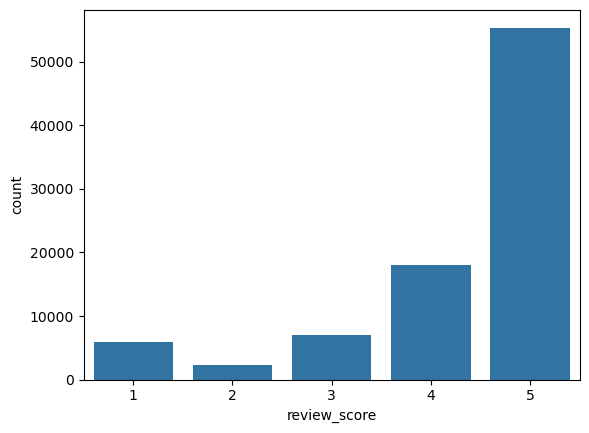

In [53]:
data_analisis_delay_review = final_data.loc[final_data["delay_time"]<0]
sns.countplot(data_analisis_delay_review, x = "review_score")

In [54]:
data_analisis_delay_review.loc[(~data_reviews["review_comment_message"].isna()) & (data_analisis_delay_review["review_score"] ==)]

SyntaxError: invalid syntax (1558685198.py, line 1)

In [ ]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

labels = [
    "Product quality",
    "Delivery time",
    "Customer service",
    "Defective product",
    "Price value",
    "Packaging",
    "Return process",
    "Matches description",
    "Overall experience"
]

text = "El pedido llegó tres días tarde y la caja venía rota."

result = classifier(text, labels)

print(result["labels"][0])